# Exploração dos dados brutos captados do MPU6050

Este notebook se trata da exploração e normalização dos dados para decisão de qual modelo deve ser treinado e implementado no esp


In [2]:
# @title Core Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%pip install seaborn
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# @title Carregando os dados

# Removido index_col=0 para que 'ax' seja lido como coluna, e não como índice
df_raw_data = pd.read_csv('./data/mpu_data.csv') 
df_raw_data.head()

,ax,ay,az,temp
0,-0.88,-11.60,-1.96,32.82
1,-1.01,-10.98,-1.06,32.79
2,-0.54,-9.29,-1.76,32.80
3,-1.58,-5.77,-6.73,32.79
4,-3.87,-7.32,-5.85,32.83


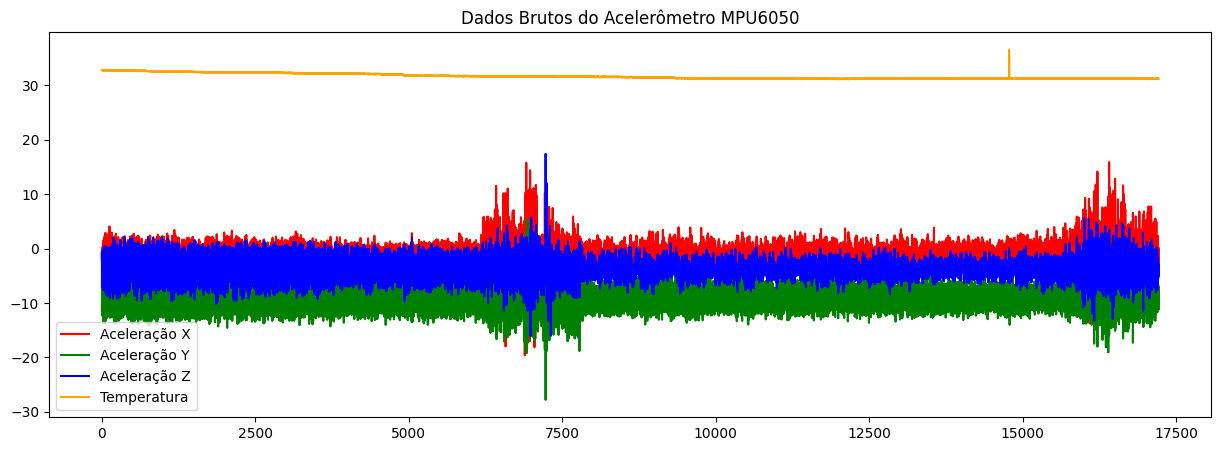

In [4]:
# @title Plotando os dados brutos

plt.figure(figsize=(15, 5))
plt.plot(df_raw_data['ax'], label='Aceleração X', color='red')
plt.plot(df_raw_data['ay'], label='Aceleração Y', color='green')
plt.plot(df_raw_data['az'], label='Aceleração Z', color='blue')
plt.plot(df_raw_data['temp'], label='Temperatura', color='orange')
plt.title('Dados Brutos do Acelerômetro MPU6050')
plt.legend()
plt.show()

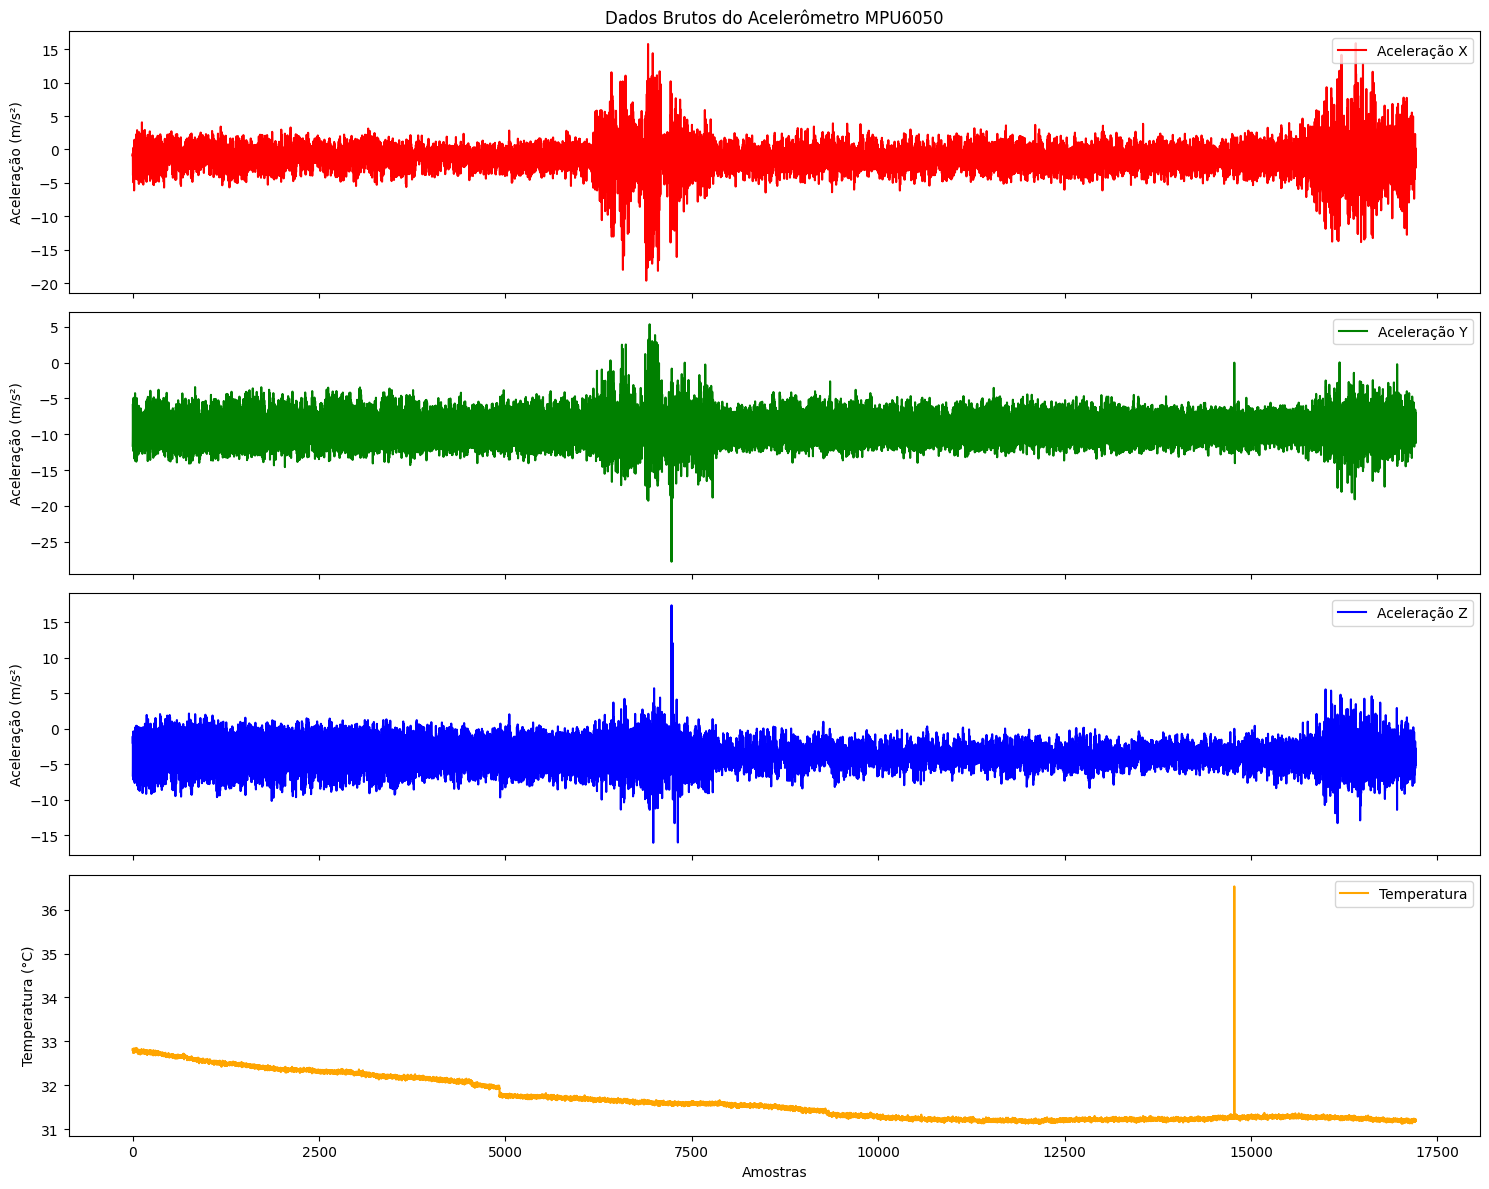

In [5]:
# @title Plotando os dados brutos separados

fig, axs = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# Aceleração X
axs[0].plot(df_raw_data['ax'], label='Aceleração X', color='red')
axs[0].set_ylabel('Aceleração (m/s²)')
axs[0].legend(loc='upper right')
axs[0].set_title('Dados Brutos do Acelerômetro MPU6050')

# Aceleração Y
axs[1].plot(df_raw_data['ay'], label='Aceleração Y', color='green')
axs[1].set_ylabel('Aceleração (m/s²)')
axs[1].legend(loc='upper right')

# Aceleração Z
axs[2].plot(df_raw_data['az'], label='Aceleração Z', color='blue')
axs[2].set_ylabel('Aceleração (m/s²)')
axs[2].legend(loc='upper right')

# Temperatura
axs[3].plot(df_raw_data['temp'], label='Temperatura', color='orange')
axs[3].set_ylabel('Temperatura (°C)')
axs[3].set_xlabel('Amostras')
axs[3].legend(loc='upper right')

plt.tight_layout()
plt.show()

### Recortando o DataFrame

Relembrando o funcionamento do ESP32, temos 1 segundo é representado por 100 amostras, dado que os dados foram extraídos a 100Hz.
<br>
Com isso em mente, separaremos em instantes de tempo para aplicar a Fast Furrier Transform (FFT) para transformar as variações de "frequência" em valores númericos, sem necessáriamente passar um vetor de alta dimensionalidade.


Antes de aplicar essa transformação dos dados, vamos criar uma feature de "magnitude" total da aceleração;


In [6]:
# @title Criando a feature de magnitude da aceleração

df_raw_data['acc_magnitude'] = np.sqrt(df_raw_data['ax']**2 + df_raw_data['ay']**2 + df_raw_data['az']**2)

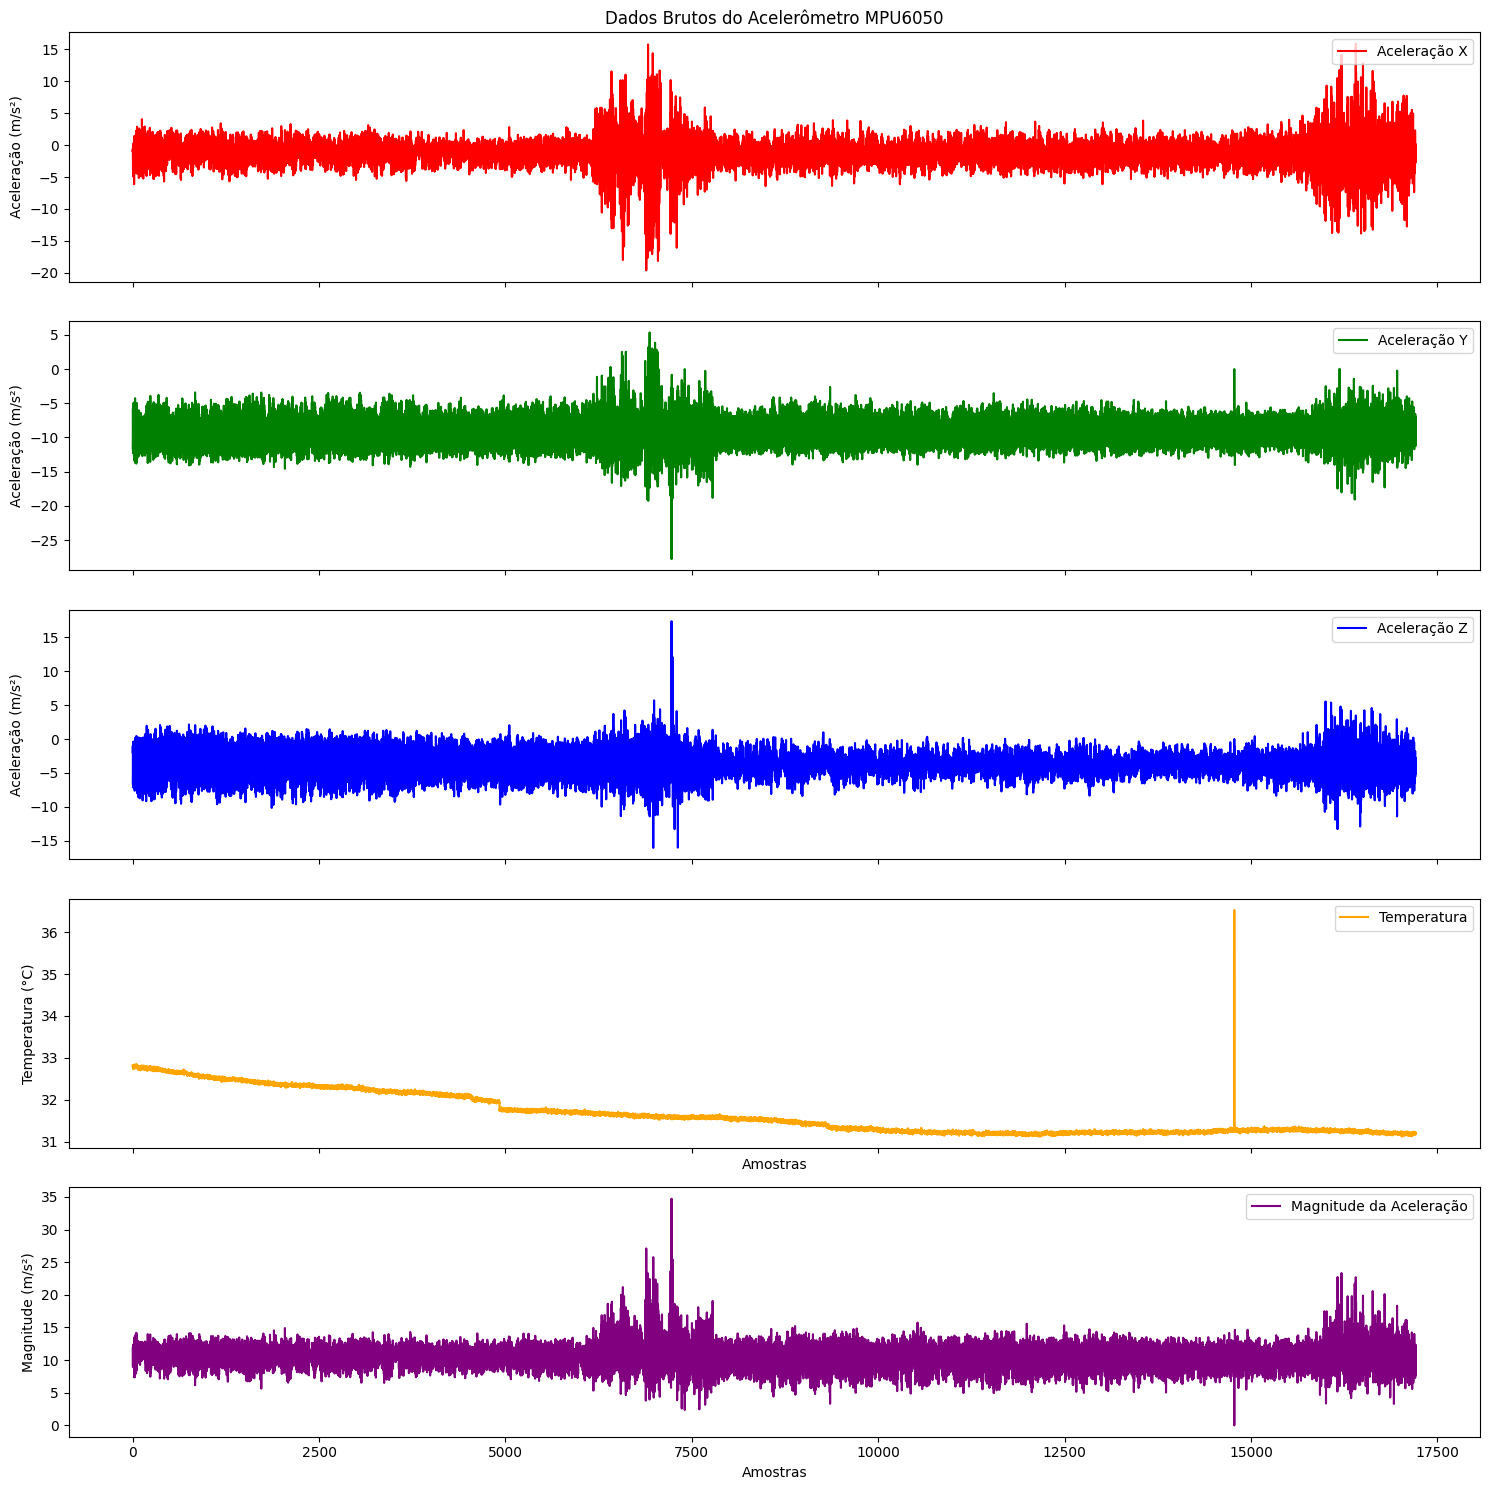

In [7]:
# @title Plotando a magnitude da aceleração

fig, axs = plt.subplots(5, 1, figsize=(15, 15), sharex=True)

# Aceleração X
axs[0].plot(df_raw_data['ax'], label='Aceleração X', color='red')
axs[0].set_ylabel('Aceleração (m/s²)')
axs[0].legend(loc='upper right')
axs[0].set_title('Dados Brutos do Acelerômetro MPU6050')

# Aceleração Y
axs[1].plot(df_raw_data['ay'], label='Aceleração Y', color='green')
axs[1].set_ylabel('Aceleração (m/s²)')
axs[1].legend(loc='upper right')

# Aceleração Z
axs[2].plot(df_raw_data['az'], label='Aceleração Z', color='blue')
axs[2].set_ylabel('Aceleração (m/s²)')
axs[2].legend(loc='upper right')

# Temperatura
axs[3].plot(df_raw_data['temp'], label='Temperatura', color='orange')
axs[3].set_ylabel('Temperatura (°C)')
axs[3].set_xlabel('Amostras')
axs[3].legend(loc='upper right')

# Magnitude da Aceleração
axs[4].plot(df_raw_data['acc_magnitude'], label='Magnitude da Aceleração', color='purple')
axs[4].set_ylabel('Magnitude (m/s²)')
axs[4].set_xlabel('Amostras')
axs[4].legend(loc='upper right')

plt.tight_layout()
plt.show()

Assim, com a magnitude coletada, vamos aplicar a FFT ao longo das janelas de 100 amostras (1 segundo).


In [8]:
# @title Função para calcular a FFT em janelas móveis de N amostras de dados

def extract_fft_features(signal, fs, window_size, step_size=None):
    """
    signal: array 1D (ex: df_raw_data['acc_mag'].values)
    fs: frequência de amostragem (Hz)
    window_size: número de amostras por janela (ex: 100)
    step_size: quantas amostras andar a cada passo (default = window_size → janelas não sobrepostas)
    """
    if step_size is None:
        step_size = window_size
        
    features = []
    n_samples = len(signal)
        
    for start in range(0, n_samples - window_size + 1, step_size):
        end = start + window_size
        window = signal[start:end]
        
        window_detrended = window - np.mean(window) # A média aqui é subtraída para remover o componente DC, que é muito forte na maioria dos sinais de aceleração.
        
        fft_values = np.fft.rfft(window_detrended)
        fft_magnitudes = np.abs(fft_values)
        
        frequencies = np.fft.rfftfreq(window_size, d=1.0/fs)
        
        fft_magnitudes_without_dc = fft_magnitudes.copy()
        fft_magnitudes_without_dc[0] = 0  # Remover o componente 0 Hz (DC) para encontrar o pico correto
        
        
        # 1° Feature -> Frequência com o maior pico
        peak_idx = np.argmax(fft_magnitudes_without_dc)
        peak_frequency = frequencies[peak_idx]
        preak_magnitude = fft_magnitudes[peak_idx]
        
        # 2° Feature -> Energia total do espectro
        energy = np.sum(fft_magnitudes_without_dc**2)
        
        features.append({
            'start_index': start,
            'peak_frequency': peak_frequency,
            'peak_magnitude': preak_magnitude,
            'energy': energy
        })   
        
    return pd.DataFrame(features)
    
        
        
        

In [9]:
# @title Extraindo as features de FFT da magnitude da aceleração

signal = df_raw_data['acc_magnitude'].values # Valores da magnitude da aceleração
fs = 100  # Frequência de amostragem em Hz
window_size = 100  # Tamanho da janela em amostras (1 segundo)
step_size = 50  # Passo da janela em amostras (50% de sobreposição)

df_fft_features = extract_fft_features(signal, fs, window_size, step_size)
df_fft_features.head()


,start_index,peak_frequency,peak_magnitude,energy
0,0,21.0,51.422403,11089.697154
1,50,19.0,25.594288,4695.446998
2,100,21.0,27.904549,5160.263974
3,150,21.0,42.844258,9114.582163
4,200,18.0,35.307787,8412.620565


Agora, com as features extraídas da FFT, vamos procurar outliers no conjunto de dados


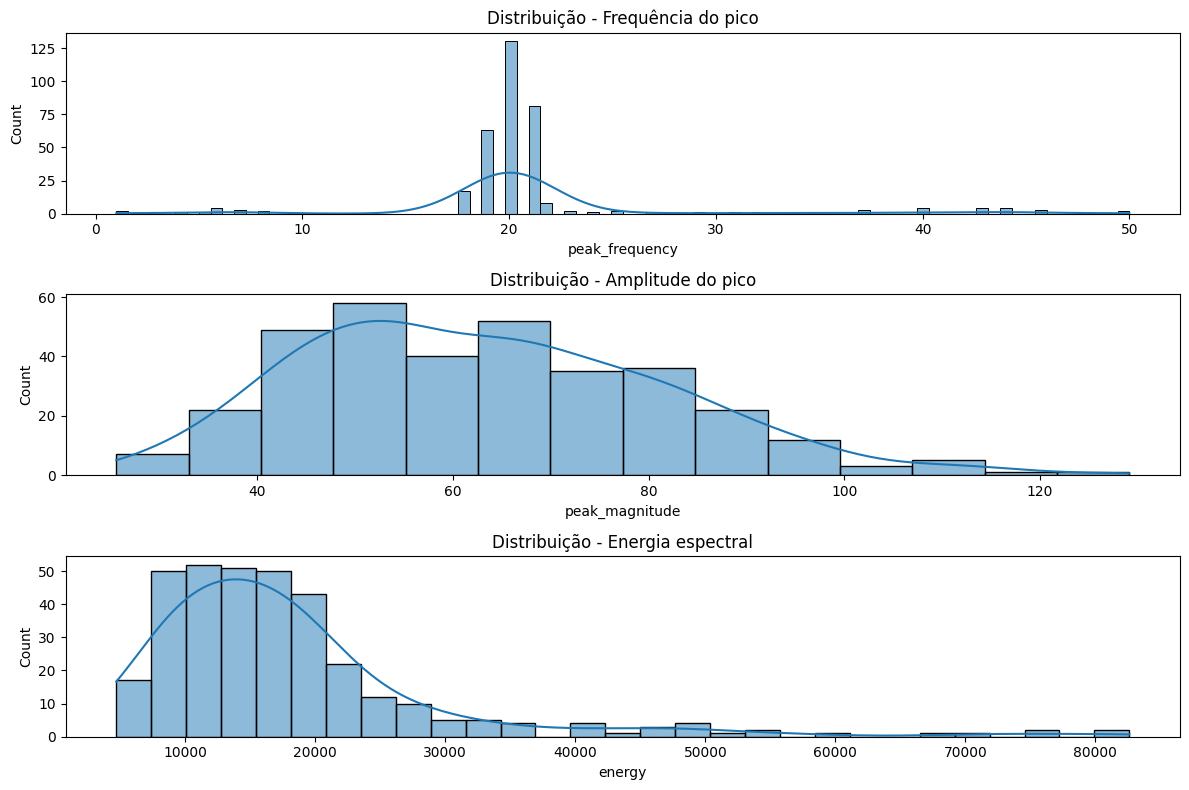

In [16]:
fig, axs = plt.subplots(3, 1, figsize=(12, 8))

sns.histplot(df_fft_features["peak_frequency"], ax=axs[0], kde=True)
axs[0].set_title("Distribuição - Frequência do pico")

sns.histplot(df_fft_features["peak_magnitude"], ax=axs[1], kde=True)
axs[1].set_title("Distribuição - Amplitude do pico")

sns.histplot(df_fft_features["energy"], ax=axs[2], kde=True)
axs[2].set_title("Distribuição - Energia espectral")

plt.tight_layout()
plt.show()



Olhando as distribuições, temos a seguintes interpretações:

1. Na distrbuição de frequência, vemos que há uma grande concentração em torno de ~19-22 Hz, portanto essa seria a assinatura de saúde do motor em que a frequência está sendo estudada, os demais valores podem significar algumas coisas, como ruído, a frequência do motor ligando e desligando ou até mesmo outliers (anomalias);
2. Na distribuição da amplitude do pico, vemos uma cauda longa a direita, indicando janelas com picos mais fortes, nos mostrando que mesmo com o motor normal a intensidade varia ao longo do tempo, ainda há alguns ruidos, mudanças de posição, e essas janelas com amplitude mais alta podem indicar pancadas ou anomalias;
3. Na distribuição do espectro de energia, temos uma distribuição assimétrica, com uma concentração entre ~8k-22k, porém há uma cauda longa até valores entre ~60k-80k. Essa energia representa o quanto houve de vibração na janela, consistindo na soma dos quadrados da magnitude, ou seja, se a magnitude cresce em um determinado momento, a energia cresce mais ainda. Então, estes valores da cauda longa indicam algumas anomalias ao longo do tempo, devido os alto valores.


### Modelo estatístico de detecção de anomalias

Considere que cada janela de 1 segundo do sinal gera duas _features_ principais:

- \( f_i \): frequência do pico (`peak_frequency`) na janela \(i\);
- \( E_i \): energia espectral total (`energy`) na janela \(i\).

#### 1. Cálculo das estatísticas da condição normal

Dado um conjunto de \( N \) janelas em condição **normal** (motor saudável), estimamos:

Média da frequência do pico:
\[
\mu*f = \frac{1}{N} \sum*{i=1}^{N} f_i
\]

Desvio-padrão da frequência do pico:
\[
\sigma*f = \sqrt{\frac{1}{N - 1} \sum*{i=1}^{N} (f_i - \mu_f)^2}
\]

Média da energia espectral:
\[
\mu*E = \frac{1}{N} \sum*{i=1}^{N} E_i
\]

Desvio-padrão da energia espectral:
\[
\sigma*E = \sqrt{\frac{1}{N - 1} \sum*{i=1}^{N} (E_i - \mu_E)^2}
\]

#### 2. Cálculo dos escores padronizados (z-score)

Para uma nova janela \( i \), calculamos o _z-score_ de cada feature:

\[
z\_{f,i} = \frac{f_i - \mu_f}{\sigma_f}
\]

\[
z\_{E,i} = \frac{E_i - \mu_E}{\sigma_E}
\]

#### 3. Combinação das features em um único escore de anomalia

Definimos um escore de anomalia combinado como:

\[
S*i = \sqrt{z*{f,i}^2 + z\_{E,i}^2}
\]

Esse escore cresce quando a frequência do pico ou a energia se afastam do comportamento normal.

#### 4. Regra de decisão (outlier)

Escolhemos um limiar \( \tau \) (por exemplo, \( \tau = 3 \) ou \( \tau = 4 \)).  
A janela \( i \) é considerada **anômala** se:

\[
S_i > \tau
\]

Caso contrário, ela é considerada **normal**:

\[
S_i \le \tau
\]


Visto este modelo estatistico para a identificação de outliers, implementar uma função para caracterizar essas anomalias e dar as suas labels


In [ ]:
# @title Implementação da função para identificar anomalias estatísticas

def identificador_anomalias(df, threshold=3.0):
    df_out = df.copy()

    # --- Estatísticas globais ---
    mu_f = df_out["peak_frequency"].mean()
    sigma_f = df_out["peak_frequency"].std(ddof=1)

    mu_E = df_out["energy"].mean()
    sigma_E = df_out["energy"].std(ddof=1)

    # Evita divisão por zero (caso de variância muito baixa)
    if sigma_f == 0:
        sigma_f = 1e-9
    if sigma_E == 0:
        sigma_E = 1e-9

    # --- Z-scores ---
    df_out["z_peak_frequency"] = (df_out["peak_frequency"] - mu_f) / sigma_f
    df_out["z_energy"] = (df_out["energy"] - mu_E) / sigma_E

    # --- Score combinado S_i = sqrt(z_f^2 + z_E^2) ---
    df_out["anomaly_score"] = np.sqrt(
        df_out["z_peak_frequency"]**2 + df_out["z_energy"]**2
    )

    # --- Regra de decisão ---
    df_out["is_anomaly"] = df_out["anomaly_score"] > threshold

    return df_out

In [18]:
# @title Aplicação da função para identificar anomalias

df_fft_anom = identificador_anomalias(df_fft_features, threshold=3.0)
df_fft_anom.head()


,start_index,peak_frequency,peak_magnitude,energy,z_peak_frequency,z_energy,anomaly_score,is_anomaly
0,0,21.0,51.422403,11089.697154,-0.005873,-0.591222,0.591251,False
1,50,19.0,25.594288,4695.446998,-0.315771,-1.118931,1.162634,False
2,100,21.0,27.904549,5160.263974,-0.005873,-1.080570,1.080586,False
3,150,21.0,42.844258,9114.582163,-0.005873,-0.754226,0.754249,False
4,200,18.0,35.307787,8412.620565,-0.470720,-0.812158,0.938711,False


In [19]:
# @title Contagem de anomalias estatísticas detectadas

df_fft_anom["is_anomaly"].value_counts()

is_anomaly
False    313
True      30
Name: count, dtype: int64